# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

In [7]:
# added matplot
import matplotlib.pyplot as plt

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

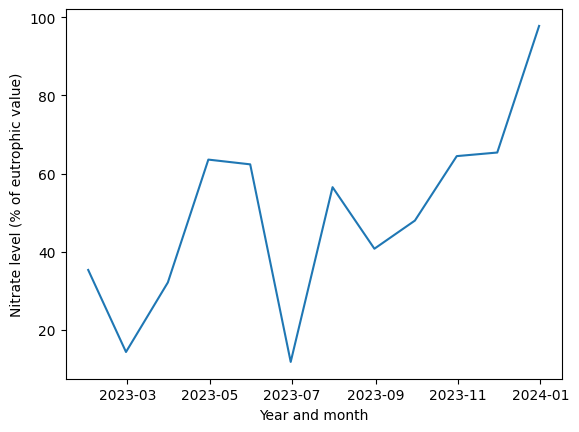

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

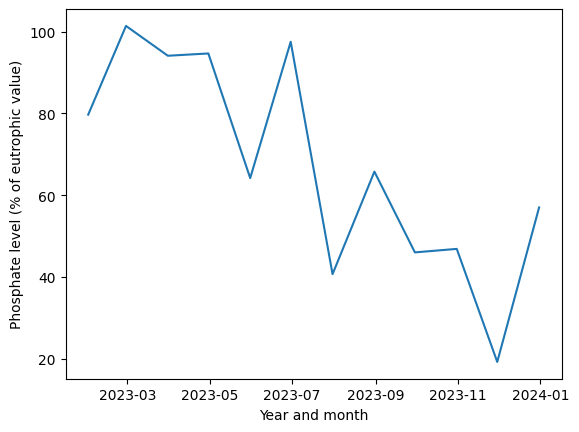

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

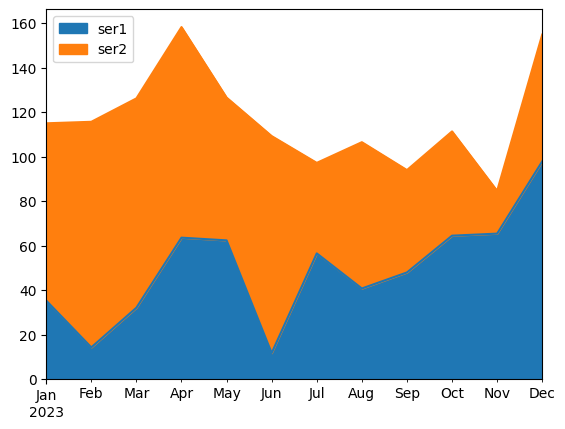

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Loading in both Datasets

In [2]:
# Load in dataset
default_credit = pd.read_excel("Default_of_Credit_Card_Clients.xls")
bankruptcy_prediction = pd.read_csv("Taiwanese_Bankruptcy_Prediction.csv")

Making all needed changes I've found in Weeks 2 and 4:

In [3]:
# changong row 0 to be header and removing original header
default_credit.columns = default_credit.iloc[0]   
default_credit = default_credit[1:]  

# changing all cols from objects to integers
default_credit = default_credit.astype(int)

#changing percent symbol to _pct
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.replace('%', '_pct')

# taking away space in front of each col name
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.strip()

## Default of Credit Card Clients Dataset Analysis:

When looking at my histograms from week 4, two columns that I thought could potentially be related was age and limit bal. In the folloing code blocks I will explore this by using information from last week.

In [14]:
sample = default_credit[['AGE', 'LIMIT_BAL']]

<Axes: xlabel='AGE', ylabel='LIMIT_BAL'>

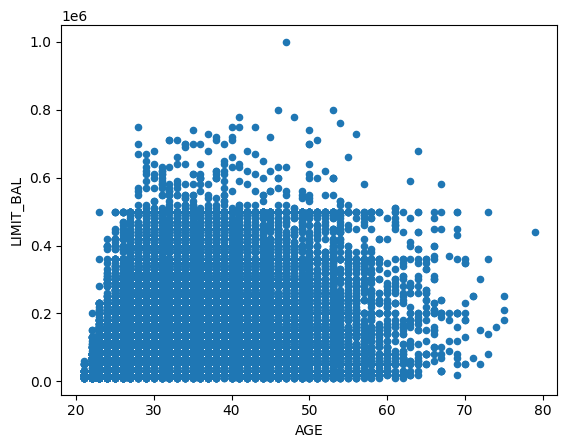

In [16]:
sample.plot.scatter(x = "AGE", y = "LIMIT_BAL")

Looking at my scatter plot above, I see that most of the data is lumped in the lower left corner. There is also so outliers arounf the overall shape like the very high point in the 40 to 50 range. While I do think the grpah has a positive correlation number, this correlation does not appear high.

In [17]:
# Checking correlation
print("Correlations:", sample.corr())

Correlations: 0               AGE  LIMIT_BAL
0                             
AGE        1.000000   0.144713
LIMIT_BAL  0.144713   1.000000


As shown in the above, the is practically no correlation between age and LIMIT_BAL, unlike I had thought. Although this is not what I expected, I still do think this data is usable and I just need to do future analysis to see if other feature have an affect on credit limit.

## Taiwanese Backruptcy Prediction Analysis:

In my Week 4 homework, I said that I thought certain histograms were related. Specifically my ROA graph. By using my knowledge from the Week 5 homework, I will be checking the level of correlation between the column pairs.

In [6]:
roa_df = bankruptcy_prediction[['ROA(C) before interest and depreciation before interest',
 'ROA(A) before interest and _pct after tax',
 'ROA(B) before interest and depreciation after tax']]

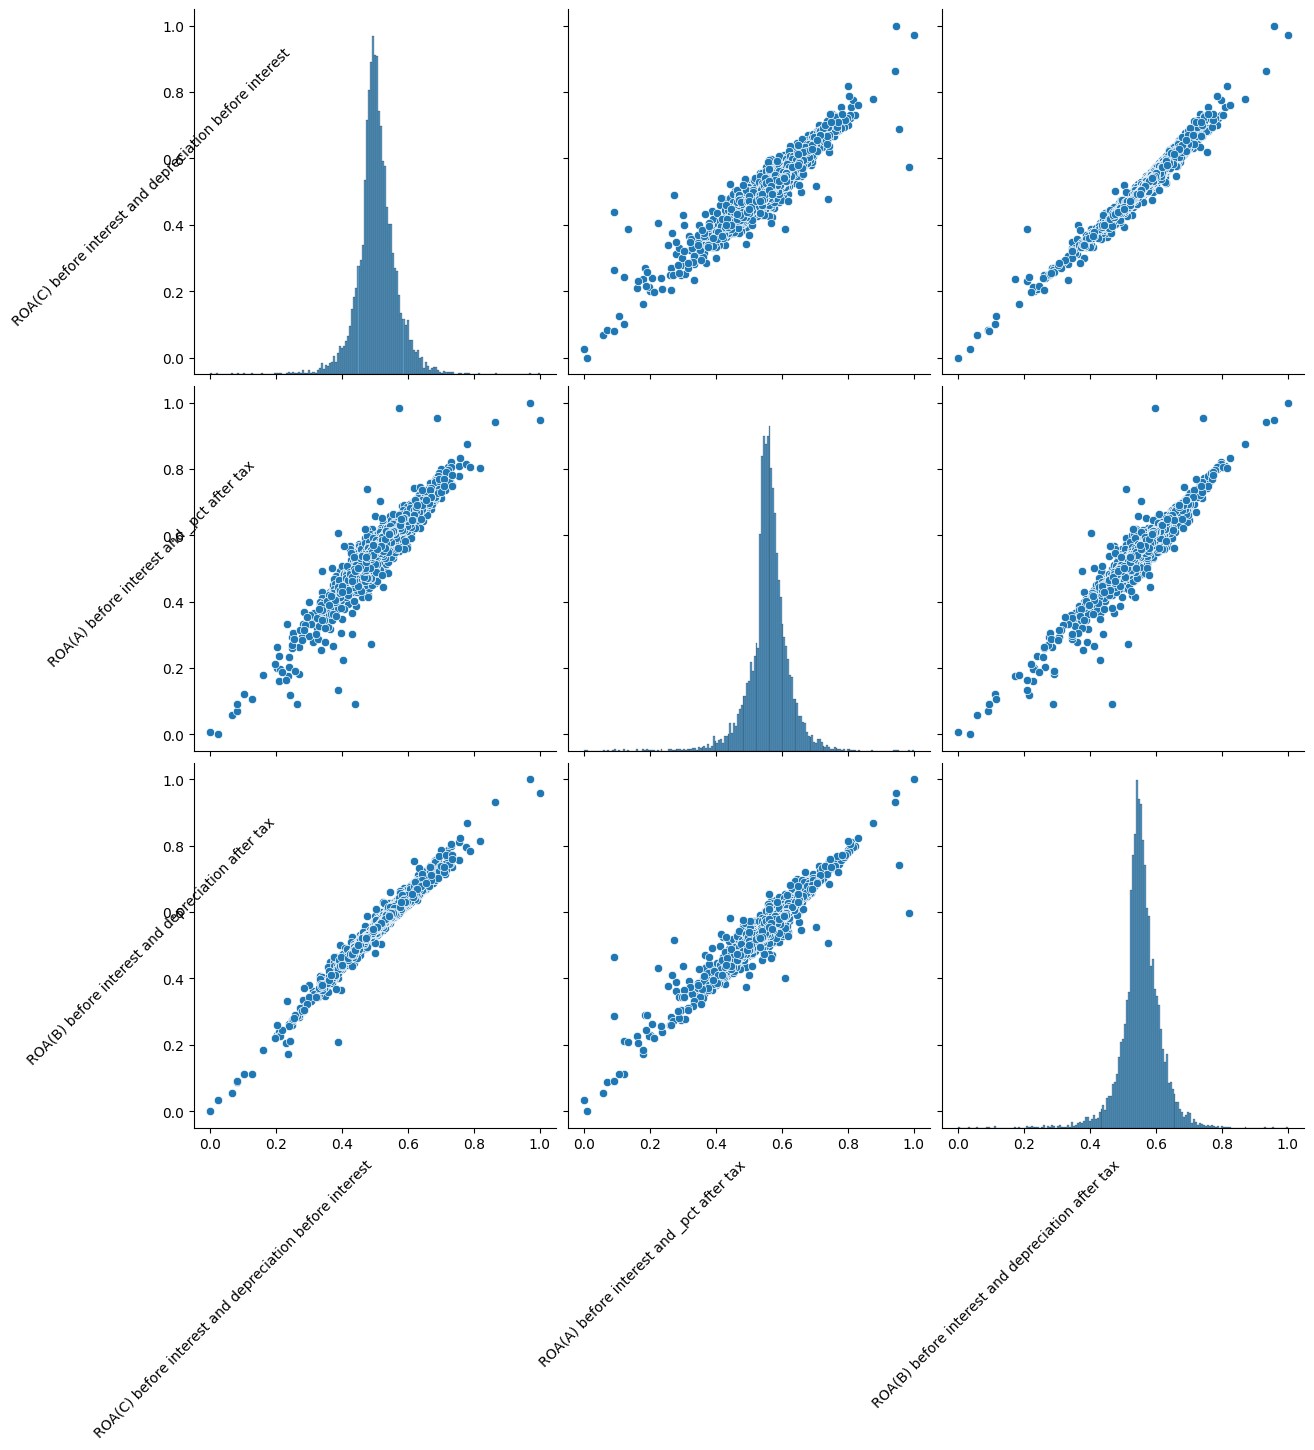

In [ ]:
g = sns.pairplot(roa_df, height=4)
g.fig.set_size_inches(12, 12) 
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=45)

plt.show()

In [13]:
print("Correlations:", roa_df.corr())

Correlations:                                                     ROA(C) before interest and depreciation before interest  \
ROA(C) before interest and depreciation before ...                                           1.000000         
ROA(A) before interest and _pct after tax                                                    0.940124         
ROA(B) before interest and depreciation after tax                                            0.986849         

                                                    ROA(A) before interest and _pct after tax  \
ROA(C) before interest and depreciation before ...                                   0.940124   
ROA(A) before interest and _pct after tax                                            1.000000   
ROA(B) before interest and depreciation after tax                                    0.955741   

                                                    ROA(B) before interest and depreciation after tax  
ROA(C) before interest and depreciation before .

As seen in the graphs above, the column pairs have very high levels of correlation which makes sense as they all relate to ROA. However, this could also possibily mean that this data is a bit redundant and that 3 seperate ROA columns is not needed. However, this does not suggest any issues with the data so far and even with the potentail of redundancy, I believe the data is still usable.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

/var/folders/r0/dkvgg52s5t3b41fnp347w0sr0000gn/T/ipykernel_27847/1753557751.py:15: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, linestyle='--', alpha=0.5)


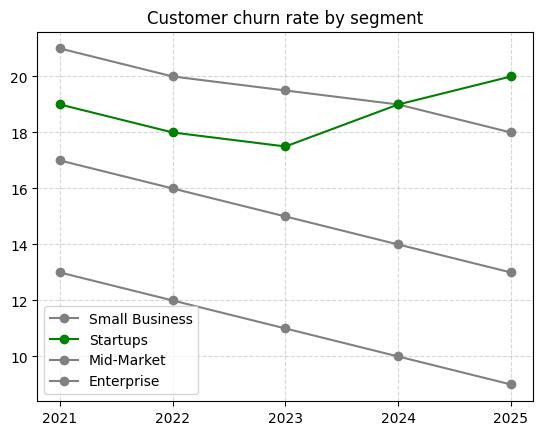

In [21]:
years = ['2021', '2022', '2023', '2024', '2025']
small_bis = [21, 20, 19.5, 19, 18]
startups = [19, 18, 17.5, 19, 20]
mid_market = [17, 16, 15, 14, 13]
enterprise= [13, 12, 11, 10, 9]

plt.plot(years, small_bis, marker='o', label='Small Business', color = 'grey')
plt.plot(years, startups, marker='o', label='Startups', color='green')
plt.plot(years, mid_market, marker='o', label='Mid-Market', color = 'grey')
plt.plot(years, enterprise, marker='o', label='Enterprise', color = 'grey')
plt.legend()

plt.title('Customer churn rate by segment')
plt.xticks(years)
plt.grid(False, linestyle='--', alpha=0.5)